In [1]:
import camb
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import pysm3
import pysm3.units as u

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

mpl.rcParams['font.family']       = 'serif'
mpl.rcParams['font.serif']        = ['DejaVu Serif', 'Times New Roman', 'serif']
mpl.rcParams['mathtext.fontset']  = 'dejavuserif'   
mpl.rcParams['text.usetex']       = False            

mpl.rcParams['font.size']         = 14
mpl.rcParams['axes.titlesize']    = 15
mpl.rcParams['axes.labelsize']    = 14
mpl.rcParams['xtick.labelsize']   = 12
mpl.rcParams['ytick.labelsize']   = 12
mpl.rcParams['legend.fontsize']   = 12
mpl.rcParams['legend.title_fontsize'] = 13


mpl.rcParams['figure.dpi'] = 120
mpl.rcParams['savefig.dpi']       = 600         
mpl.rcParams['savefig.bbox']      = 'tight'
mpl.rcParams['savefig.format']    = 'pdf'       

mpl.rcParams['axes.spines.top']   = True
mpl.rcParams['axes.spines.right'] = True
mpl.rcParams['axes.edgecolor']    = 'black'
mpl.rcParams['axes.linewidth']    = 1.2  


N_colores = 8                                      
cmap      = mpl.colormaps['rainbow']               
colores   = [cmap(i / (N_colores - 1)) for i in range(N_colores)]
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=colores)

# --- Grilla ---
mpl.rcParams['axes.grid']         = True
mpl.rcParams['grid.color']        = '0.85'
mpl.rcParams['grid.linestyle']    = '--'
mpl.rcParams['grid.linewidth']    = 0.6
mpl.rcParams['grid.alpha']        = 0.7

# --- Ticks ---
mpl.rcParams['xtick.direction']   = 'in'
mpl.rcParams['ytick.direction']   = 'in'
mpl.rcParams['xtick.major.size']  = 5
mpl.rcParams['ytick.major.size']  = 5
mpl.rcParams['xtick.minor.size']  = 3
mpl.rcParams['ytick.minor.size']  = 3
mpl.rcParams['xtick.major.width'] = 1.0
mpl.rcParams['ytick.major.width'] = 1.0
mpl.rcParams['xtick.minor.visible'] = True
mpl.rcParams['ytick.minor.visible'] = True

# --- Lineas y markers ---
mpl.rcParams['lines.linewidth']   = 2.0
mpl.rcParams['lines.markersize']  = 6

# --- Leyenda ---
mpl.rcParams['legend.frameon']    = True
mpl.rcParams['legend.framealpha'] = 0.85
mpl.rcParams['legend.edgecolor']  = '0.8'
mpl.rcParams['legend.fancybox']   = False

mpl.rcParams['image.cmap']        = 'rainbow'    

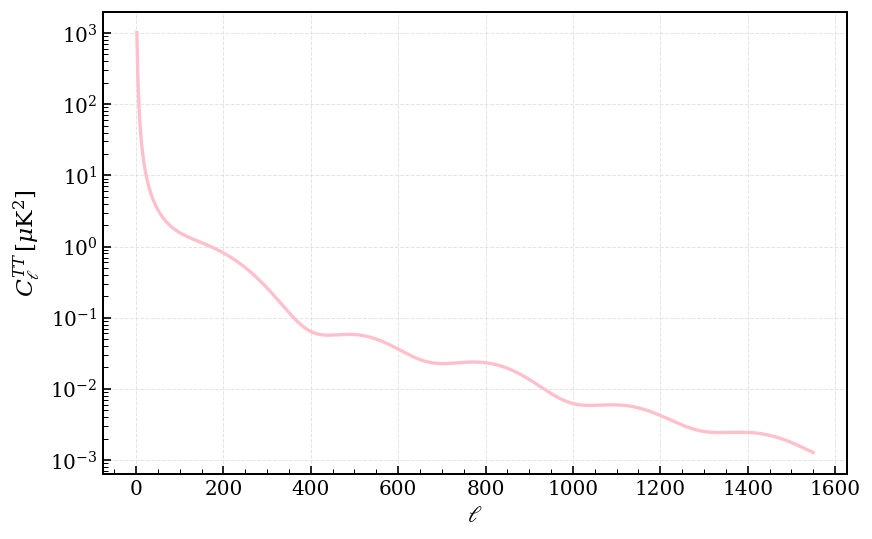

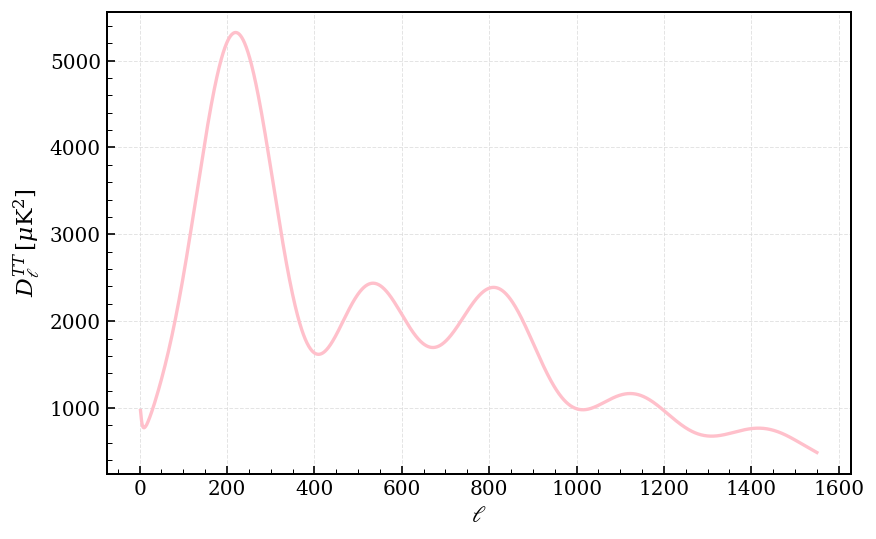

In [3]:

pars = camb.set_params(
    H0=67.5, 
    ombh2=0.022, 
    omch2=0.122, 
    mnu=0.06, 
    omk=0, 
    tau=0.06, 
    As=2e-9, 
    ns=0.965, 
    lmax=1500
)

results = camb.get_results(pars)

powers = results.get_cmb_power_spectra(pars, CMB_unit="muK", raw_cl=True) 

cl_tt = powers["lensed_scalar"][:, 0]

ells = np.arange(len(cl_tt))

cl_tt[:2] = 0.0

Dl_tt = ells * (ells + 1) * cl_tt / (2 * np.pi)

plt.figure(figsize=(8,5))
plt.plot(ells[2:], cl_tt[2:], color='pink')
plt.yscale("log")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_\ell^{TT}\,[\mu \mathrm{K}^2]$")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(ells[2:], Dl_tt[2:], color='pink')
plt.xlabel(r"$\ell$")
plt.ylabel(r"$D_\ell^{TT}\,[\mu \mathrm{K}^2]$")
plt.show()

In [4]:
ells

array([   0,    1,    2, ..., 1548, 1549, 1550], shape=(1551,))

/tmp/ipykernel_1889/3983545465.py:5: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  alm_master = hp.synalm(cl_tt, lmax=lmax_master, new=True, verbose=False)
/tmp/ipykernel_1889/3983545465.py:9: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  map_512 = hp.alm2map(alm, nside=nside, lmax=lmax_map, pol=False, verbose=False)


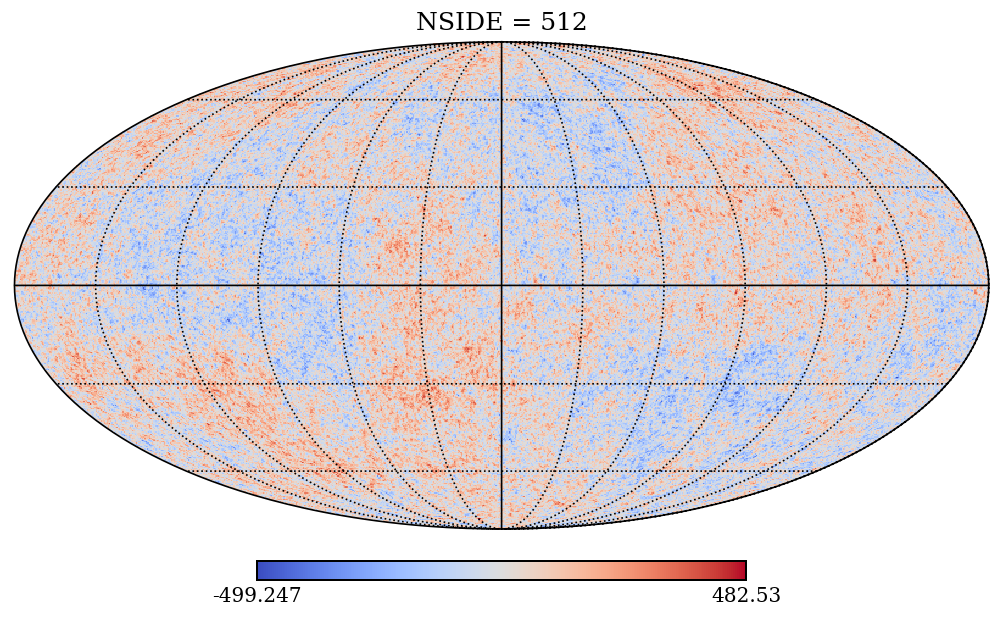

In [5]:
seed = 207790273
np.random.seed(seed)

lmax_master = len(cl_tt) - 1
alm_master = hp.synalm(cl_tt, lmax=lmax_master, new=True, verbose=False)
nside = 512
lmax_map = min(lmax_master, 3*nside - 1)
alm = hp.resize_alm(alm_master, lmax=lmax_master, mmax=lmax_master, lmax_out=lmax_map, mmax_out=lmax_map)
map_512 = hp.alm2map(alm, nside=nside, lmax=lmax_map, pol=False, verbose=False)


hp.mollview(map_512, title=f"NSIDE = {nside}", cmap="coolwarm")
hp.graticule()
plt.show()

In [6]:
print(f"Número de pixeles en este mapa (NSIDIE=512):", len(map_512))

Número de pixeles en este mapa (NSIDIE=512): 3145728


In [7]:
12*512*512

3145728

In [8]:
temp_promedio = np.mean(map_512)
temp_desv = np.std(map_512)
print(f"Temperatura promedio: {temp_promedio:.9f} microK")

Temperatura promedio: 0.000026131 microK


In [9]:
seed = 113403063
rng = np.random.default_rng(seed)

npix = 12*512*512

pix_elegido = rng.integers(0, npix)

theta_pix, phi_pix = hp.pix2ang(nside, pix_elegido)

vec0 = hp.ang2vec(theta_pix, phi_pix)

temp0 = map_512[pix_elegido]

print("Pixel elegido:", pix_elegido)
print("theta [rad]:", theta_pix)
print("phi [rad]:", phi_pix)
print("Temperatura en ese punto [microK]:", temp0)

Pixel elegido: 1924277
theta [rad]: 1.7966704155219448
phi [rad]: 0.5568350260024878
Temperatura en ese punto [microK]: 224.71349817311275


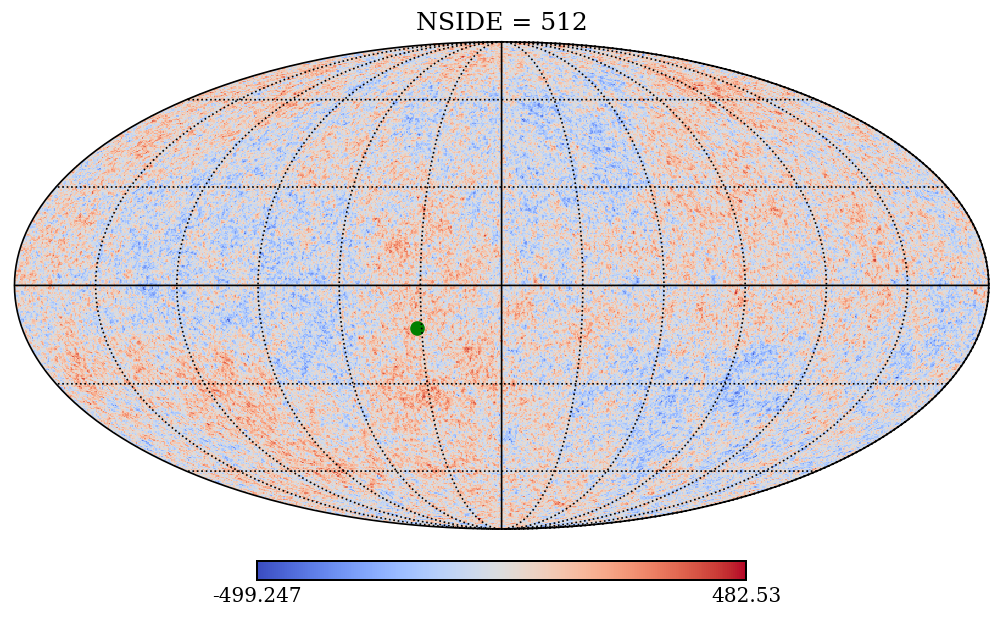

In [10]:
hp.mollview(map_512, title=f"NSIDE = {nside}", cmap="coolwarm")
hp.projscatter(theta_pix, phi_pix, marker="o", s=60, color='green')
hp.graticule()
plt.show()

In [11]:
r_interno = 0.2
r_externo = 0.7

r_interno_rad = np.radians(r_interno)
r_externo_rad = np.radians(r_externo)


pix_disco_externo = hp.query_disc(nside=nside, vec=vec0, radius=r_externo_rad, inclusive=True)
pix_disco_interno = hp.query_disc( nside=nside, vec=vec0, radius=r_interno_rad, inclusive=True)


pix_anillo = np.setdiff1d(pix_disco_externo, pix_disco_interno)

temp_anillo = map_512[pix_anillo]

temp_anillo_mean = np.mean(temp_anillo)

print("Número de pixeles en el disco externo:", len(pix_disco_externo))
print("Número de pixeles en el disco interno:", len(pix_disco_interno))
print("Número de pixeles en el anillo:", len(pix_anillo))
print("Temperatura promedio del anillo [microK]:", temp_anillo_mean)

Número de pixeles en el disco externo: 147
Número de pixeles en el disco interno: 21
Número de pixeles en el anillo: 126
Temperatura promedio del anillo [microK]: 159.9630813938737


In [23]:
r_interno = 30.2
r_externo = 31.7

r_interno_rad = np.radians(r_interno)
r_externo_rad = np.radians(r_externo)


pix_disco_externo = hp.query_disc(nside=nside, vec=vec0, radius=r_externo_rad, inclusive=True)
pix_disco_interno = hp.query_disc( nside=nside, vec=vec0, radius=r_interno_rad, inclusive=True)


pix_anillo = np.setdiff1d(pix_disco_externo, pix_disco_interno)

temp_anillo = map_512[pix_anillo]

temp_anillo_mean = np.mean(temp_anillo)

print("Número de pixeles en el disco externo:", len(pix_disco_externo))
print("Número de pixeles en el disco interno:", len(pix_disco_interno))
print("Número de pixeles en el anillo:", len(pix_anillo))
print("Temperatura promedio del anillo [microK]:", temp_anillo_mean)

Número de pixeles en el disco externo: 235932
Número de pixeles en el disco interno: 214644
Número de pixeles en el anillo: 21288
Temperatura promedio del anillo [microK]: 21.59819182101713


In [ ]:
temperatura_anillos = []
radios_medios = []

r_interno_anillo = 0.2
ancho_anillo = 0.5
r_externo_total = 30.2

while r_interno_anillo < r_externo_total:
    
    r_externo_anillo = r_interno_anillo + ancho_anillo
    
    pix_disco_externo = hp.query_disc(nside=nside, vec=vec0, radius=np.radians(r_externo_anillo), inclusive=True)

    pix_disco_interno = hp.query_disc(nside=nside, vec=vec0, radius=np.radians(r_interno_anillo), inclusive=True)

    pix_anillo = np.setdiff1d(pix_disco_externo, pix_disco_interno)

    temp_media = np.mean(map_512[pix_anillo])

    temperatura_anillos.append(temp_media)
    radios_medios.append((r_interno_anillo + r_externo_anillo) / 2)

    r_interno_anillo = r_externo_anillo

In [14]:
radios_medios

[0.44999999999999996,
 0.95,
 1.45,
 1.9500000000000002,
 2.45,
 2.95,
 3.45,
 3.95,
 4.45,
 4.95,
 5.45,
 5.95,
 6.45,
 6.95,
 7.45,
 7.949999999999999,
 8.45,
 8.95,
 9.45,
 9.95,
 10.45,
 10.95,
 11.45,
 11.95,
 12.45,
 12.95,
 13.45,
 13.95,
 14.45,
 14.95,
 15.45,
 15.95,
 16.45,
 16.95,
 17.45,
 17.95,
 18.45,
 18.95,
 19.45,
 19.95,
 20.45,
 20.95,
 21.45,
 21.95,
 22.45,
 22.95,
 23.45,
 23.95,
 24.45,
 24.95,
 25.45,
 25.95,
 26.45,
 26.95,
 27.45,
 27.95,
 28.45,
 28.95,
 29.45,
 29.95]

In [13]:
temperatura_anillos

[np.float64(159.9630813938737),
 np.float64(135.9842007081648),
 np.float64(115.75347143531948),
 np.float64(146.80130219784186),
 np.float64(112.86277572047779),
 np.float64(95.93112406793453),
 np.float64(99.71560792508059),
 np.float64(86.11567231033003),
 np.float64(66.9288258306027),
 np.float64(49.149062772212325),
 np.float64(62.56958351133154),
 np.float64(64.46135123544244),
 np.float64(57.06499404991467),
 np.float64(50.150685633893595),
 np.float64(53.37728248401909),
 np.float64(54.595386598484225),
 np.float64(63.88439288310694),
 np.float64(67.16318203334001),
 np.float64(40.22848387914157),
 np.float64(49.207303157928145),
 np.float64(68.05075489899764),
 np.float64(57.08490702199921),
 np.float64(43.3488243968794),
 np.float64(39.58721940365427),
 np.float64(37.69314503615537),
 np.float64(37.588745297661),
 np.float64(31.95253360176137),
 np.float64(36.21863466848775),
 np.float64(32.242492826559236),
 np.float64(34.84968718075953),
 np.float64(38.64991857092676),
 np.

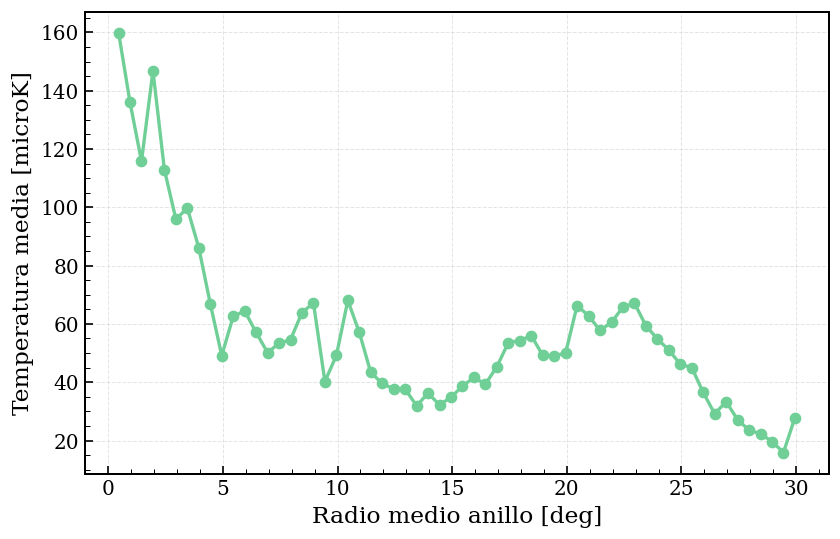

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(radios_medios, temperatura_anillos, marker="o", linestyle="-", color='#6FCF97')

plt.xlabel("Radio medio anillo [deg]")
plt.ylabel("Temperatura media [microK]")

plt.grid(True)
plt.show()

In [ ]:
rng = np.random.default_rng(seed)
npix = 12*512*512
pix_elegido = rng.integers(0, npix)
theta_pix, phi_pix = hp.pix2ang(nside, pix_elegido)
vec_i = hp.ang2vec(theta_pix, phi_pix)
temp0 = map_512[pix_elegido]


temperatura_anillos_i = []
radios_medios_i = []

r_interno_anillo = 0.2
ancho_anillo = 0.5
r_externo_total = 30.2

while r_interno_anillo < r_externo_total:
    
    r_externo_anillo = r_interno_anillo + ancho_anillo
    pix_disco_externo = hp.query_disc(nside=nside, vec=vec_i, radius=np.radians(r_externo_anillo), inclusive=True)
    pix_disco_interno = hp.query_disc(nside=nside, vec=vec_i, radius=np.radians(r_interno_anillo), inclusive=True)
    pix_anillo = np.setdiff1d(pix_disco_externo, pix_disco_interno)
    temp_media = np.mean(map_512[pix_anillo])
    temperatura_anillos.append(temp_media)
    radios_medios.append((r_interno_anillo + r_externo_anillo) / 2)

    r_interno_anillo = r_externo_anillo


    

In [31]:
seed = 113403063
rng = np.random.default_rng(seed)
n_puntos = 1000
npix = hp.nside2npix(nside)

r_inicial = 0.2
r_final = 30.2
ancho_anillo = 0.5
bordes_radiales = np.arange(r_inicial, r_final + ancho_anillo, ancho_anillo)

radios_internos = bordes_radiales[:-1]
radios_externos = bordes_radiales[1:]
radios_medios = (radios_internos + radios_externos) / 2
temperaturas_todos_los_puntos = []
pixeles_elegidos = []
temps_puntos = []

for i in range(n_puntos):
    
    pix_elegido = rng.integers(0, npix)
    theta_pix, phi_pix = hp.pix2ang(nside, pix_elegido)
    vec_i = hp.ang2vec(theta_pix, phi_pix)
    temp0 = map_512[pix_elegido]
    temperatura_anillos_i = []

    for r_interno_anillo, r_externo_anillo in zip(radios_internos, radios_externos):
        pix_disco_externo = hp.query_disc(nside=nside, vec=vec_i, radius=np.radians(r_externo_anillo), inclusive=True)
        pix_disco_interno = hp.query_disc(nside=nside, vec=vec_i, radius=np.radians(r_interno_anillo), inclusive=True)
        pix_anillo = np.setdiff1d(pix_disco_externo, pix_disco_interno)
        temp_media = np.mean(map_512[pix_anillo])
        temperatura_anillos_i.append(temp_media)

    temperaturas_todos_los_puntos.append(temperatura_anillos_i)
    pixeles_elegidos.append(pix_elegido)
    temps_puntos.append(temp0)

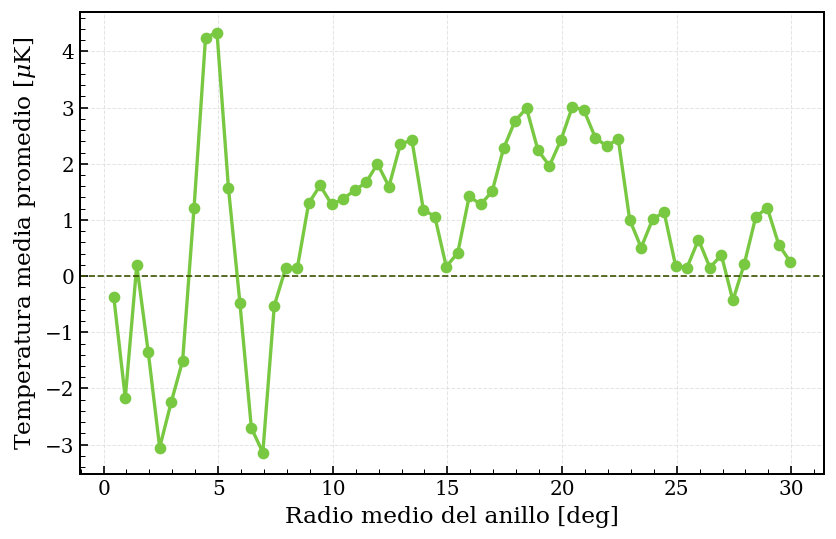

In [ ]:
temperaturas_todos_los_puntos = np.array(temperaturas_todos_los_puntos)

perfil_promedio = np.mean(temperaturas_todos_los_puntos, axis=0)

plt.figure(figsize=(8, 5))
plt.plot(radios_medios, perfil_promedio, marker="o", linestyle="-", color='#78C841')
plt.axhline(0, linestyle="--", linewidth=1, color='#3D5300')
plt.xlabel("Radio medio del anillo [deg]")
plt.ylabel(r"Temperatura media promedio [$\mu$K]")



plt.grid(True)
plt.show()

In [27]:
temperaturas_todos_los_puntos

array([[159.96308139, 135.98420071, 115.75347144, ...,  19.64886789,
         15.89476401,  27.89232865],
       [  2.39381617, -59.15229037, -89.42513745, ..., -32.28168578,
        -41.48346151, -43.98610719],
       [ 14.88190798,  -4.59159885,   3.58654201, ..., -21.8082844 ,
        -24.4769101 , -32.16817569],
       ...,
       [-65.54283787, -48.95339586, -77.32567243, ...,   7.45492441,
         10.94447318,  15.34627951],
       [-43.98021935, -31.87624359, -12.60995036, ...,  29.04040258,
         24.82188666,  17.07828425],
       [ 32.87044552, -39.37773368, -24.67059987, ...,  -4.51347865,
         -2.62061924, -12.45440451]], shape=(100, 60))

In [ ]:
seed = 113403063
rng = np.random.default_rng(seed)
n_puntos = 10000
npix = hp.nside2npix(nside)

r_inicial = 0.2
r_final = 30.2
ancho_anillo = 0.5
bordes_radiales = np.arange(r_inicial, r_final + ancho_anillo, ancho_anillo)

radios_internos = bordes_radiales[:-1]
radios_externos = bordes_radiales[1:]
radios_medios = (radios_internos + radios_externos) / 2
temperaturas_todos_los_puntos = []
pixeles_elegidos = []
temps_puntos = []

for i in range(n_puntos):
    
    pix_elegido = rng.integers(0, npix)
    theta_pix, phi_pix = hp.pix2ang(nside, pix_elegido)
    vec_i = hp.ang2vec(theta_pix, phi_pix)
    temp0 = map_512[pix_elegido]
    temperatura_anillos_i = []

    for r_interno_anillo, r_externo_anillo in zip(radios_internos, radios_externos):
        pix_disco_externo = hp.query_disc(nside=nside, vec=vec_i, radius=np.radians(r_externo_anillo), inclusive=True)
        pix_disco_interno = hp.query_disc(nside=nside, vec=vec_i, radius=np.radians(r_interno_anillo), inclusive=True)
        pix_anillo = np.setdiff1d(pix_disco_externo, pix_disco_interno)
        temp_media = np.mean(map_512[pix_anillo])
        temperatura_anillos_i.append(temp_media)

    temperaturas_todos_los_puntos.append(temperatura_anillos_i)
    pixeles_elegidos.append(pix_elegido)
    temps_puntos.append(temp0)

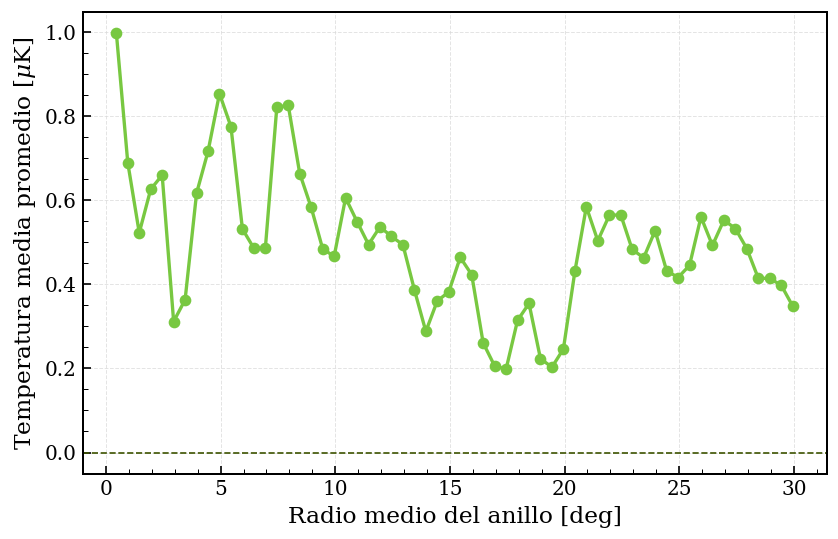

In [ ]:
temperaturas_todos_los_puntos = np.array(temperaturas_todos_los_puntos)

perfil_promedio = np.mean(temperaturas_todos_los_puntos, axis=0)

plt.figure(figsize=(8, 5))
plt.plot(radios_medios, perfil_promedio, marker="o", linestyle="-", color='#78C841')
plt.axhline(0, linestyle="--", linewidth=1, color='#3D5300')
plt.xlabel("Radio medio del anillo [deg]")
plt.ylabel(r"Temperatura media promedio [$\mu$K]")



plt.grid(True)
plt.show()

In [ ]:
r_interno = 30.2
r_externo = 31.7

r_interno_rad = np.radians(r_interno)
r_externo_rad = np.radians(r_externo)


pix_disco_externo = hp.query_disc(nside=nside, vec=vec0, radius=r_externo_rad, inclusive=True)
pix_disco_interno = hp.query_disc( nside=nside, vec=vec0, radius=r_interno_rad, inclusive=True)


pix_anillo = np.setdiff1d(pix_disco_externo, pix_disco_interno)

temp_anillo = map_512[pix_anillo]

temp_anillo_mean = np.mean(temp_anillo)

print("Número de pixeles en el disco externo:", len(pix_disco_externo))
print("Número de pixeles en el disco interno:", len(pix_disco_interno))
print("Número de pixeles en el anillo:", len(pix_anillo))
print("Temperatura promedio del anillo [microK]:", temp_anillo_mean)


temperatura_anillos = []
radios_medios = []

r_interno_anillo = 0.2
ancho_anillo = 0.5
r_externo_total = 30.2

while r_interno_anillo < r_externo_total:
    
    r_externo_anillo = r_interno_anillo + ancho_anillo
    
    pix_disco_externo = hp.query_disc(nside=nside, vec=vec0, radius=np.radians(r_externo_anillo), inclusive=True)
    pix_disco_interno = hp.query_disc(nside=nside, vec=vec0, radius=np.radians(r_interno_anillo), inclusive=True)
    pix_anillo = np.setdiff1d(pix_disco_externo, pix_disco_interno)

    temp_media = np.mean(map_512[pix_anillo])

    temperatura_anillos.append(temp_media)
    radios_medios.append((r_interno_anillo + r_externo_anillo) / 2)

    r_interno_anillo = r_externo_anillo


plt.figure(figsize=(8, 5))

plt.plot(radios_medios, temperatura_anillos, marker="o", linestyle="-", color='#6FCF97')

plt.xlabel("Radio medio anillo [deg]")
plt.ylabel("Temperatura media [microK]")

plt.grid(True)
plt.show()

Número de pixeles en el disco externo: 235932
Número de pixeles en el disco interno: 214644
Número de pixeles en el anillo: 21288
Temperatura promedio del anillo [microK]: 21.59819182101713


Pixel elegido: 744498
theta [rad]: 1.016856847927738
phi [rad]: 0.15493205957644976
Temperatura en ese punto [microK]: 1.4238017540642005


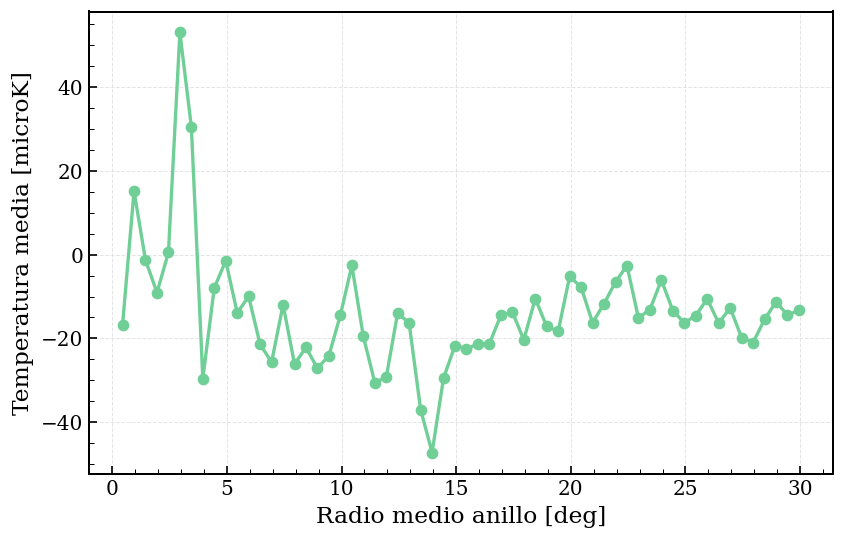

In [10]:
seed = 116
rng = np.random.default_rng(seed)

npix = 12*512*512

pix_elegido = rng.integers(0, npix)

theta_pix, phi_pix = hp.pix2ang(nside, pix_elegido)

vec0 = hp.ang2vec(theta_pix, phi_pix)

temp0 = map_512[pix_elegido]

print("Pixel elegido:", pix_elegido)
print("theta [rad]:", theta_pix)
print("phi [rad]:", phi_pix)
print("Temperatura en ese punto [microK]:", temp0)

temperatura_anillos = []
radios_medios = []

r_interno_anillo = 0.2
ancho_anillo = 0.5
r_externo_total = 30.2

while r_interno_anillo < r_externo_total:
    
    r_externo_anillo = r_interno_anillo + ancho_anillo
    
    pix_disco_externo = hp.query_disc(nside=nside, vec=vec0, radius=np.radians(r_externo_anillo), inclusive=True)

    pix_disco_interno = hp.query_disc(nside=nside, vec=vec0, radius=np.radians(r_interno_anillo), inclusive=True)

    pix_anillo = np.setdiff1d(pix_disco_externo, pix_disco_interno)

    temp_media = np.mean(map_512[pix_anillo])

    temperatura_anillos.append(temp_media)
    radios_medios.append((r_interno_anillo + r_externo_anillo) / 2)

    r_interno_anillo = r_externo_anillo

plt.figure(figsize=(8, 5))

plt.plot(radios_medios, temperatura_anillos, marker="o", linestyle="-", color='#6FCF97')

plt.xlabel("Radio medio anillo [deg]")
plt.ylabel("Temperatura media [microK]")

plt.grid(True)
plt.show()

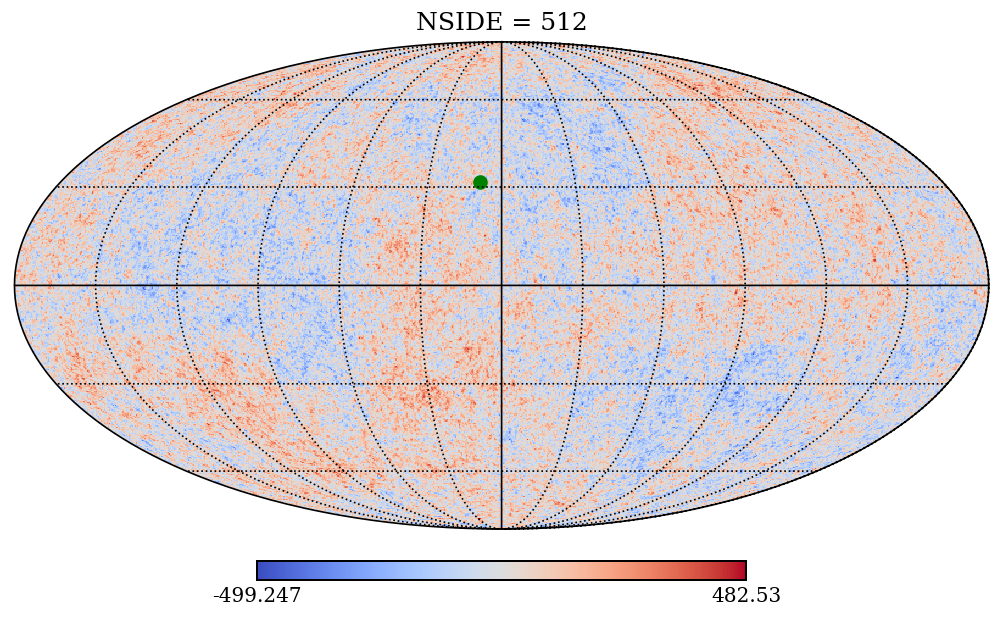

In [11]:
hp.mollview(map_512, title=f"NSIDE = {nside}", cmap="coolwarm")
hp.projscatter(theta_pix, phi_pix, marker="o", s=60, color='green')
hp.graticule()
plt.show()

In [9]:
seed = 113403063
rng = np.random.default_rng(seed)

npix = hp.nside2npix(nside)

pix_elegido = rng.integers(0, npix)

theta_pix, phi_pix = hp.pix2ang(nside, pix_elegido)

vec0 = hp.ang2vec(theta_pix, phi_pix)

temp0 = map_512[pix_elegido]

print("Pixel elegido:", pix_elegido)
print("theta [rad]:", theta_pix)
print("phi [rad]:", phi_pix)
print("Temperatura en ese punto [microK]:", temp0)

Pixel elegido: 1924277
theta [rad]: 1.7966704155219448
phi [rad]: 0.5568350260024878
Temperatura en ese punto [microK]: 224.71349817311275


In [15]:
r_interno = 0.2
r_externo = 30.2

pix_disco_externo = hp.query_disc(
    nside=nside,
    vec=vec0,
    radius=np.radians(r_externo),
    inclusive=True
)

pix_disco_interno = hp.query_disc(
    nside=nside,
    vec=vec0,
    radius=np.radians(r_interno),
    inclusive=True
)

pix_anillo = np.setdiff1d(pix_disco_externo, pix_disco_interno)

temp_anillo = map_512[pix_anillo]

temp_anillo_mean = np.mean(temp_anillo)

print("Número de píxeles en el disco externo:", len(pix_disco_externo))
print("Número de píxeles en el disco interno:", len(pix_disco_interno))
print("Número de píxeles en el anillo:", len(pix_anillo))
print("Temperatura promedio del anillo [microK]:", temp_anillo_mean)

Número de píxeles en el disco externo: 214644
Número de píxeles en el disco interno: 21
Número de píxeles en el anillo: 214623
Temperatura promedio del anillo [microK]: 45.644209403273145


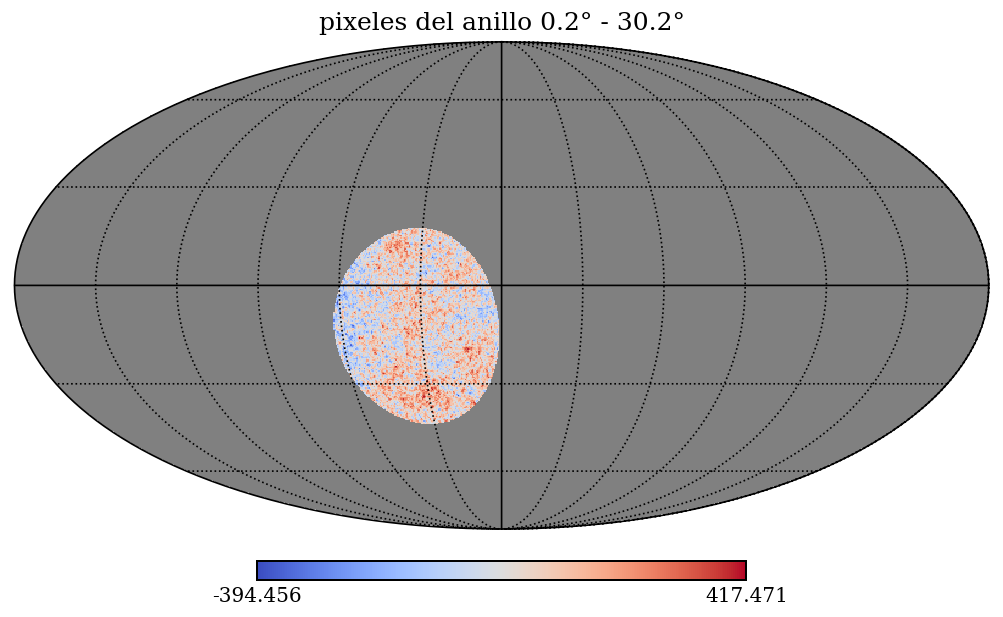

In [16]:
map_anillo = np.full(len(map_512), hp.UNSEEN)

map_anillo[pix_anillo] = map_512[pix_anillo]

hp.mollview(map_anillo, title="pixeles del anillo 0.2° - 30.2°", cmap="coolwarm")
hp.graticule()
plt.show()